In [1]:
import tensorflow as tf
from tensorflow.keras import layers

In [2]:
import matplotlib.pyplot as plt

In [3]:
image_size = 256
batch_size = 32
epochs = 50

In [4]:
dataset = tf.keras.preprocessing.image_dataset_from_directory(
    "plantvillage",
    labels='inferred',
    label_mode='int',
    class_names=None,
    color_mode='rgb',
    batch_size=32,
    image_size=(256, 256),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation='bilinear',
    follow_links=False,
    crop_to_aspect_ratio=False,
    pad_to_aspect_ratio=False,
    data_format=None,
    verbose=True
)

Found 20638 files belonging to 15 classes.


In [5]:
class_names = dataset.class_names
print(class_names)

['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']


In [6]:
len(dataset)

645

In [7]:
645*32

20640

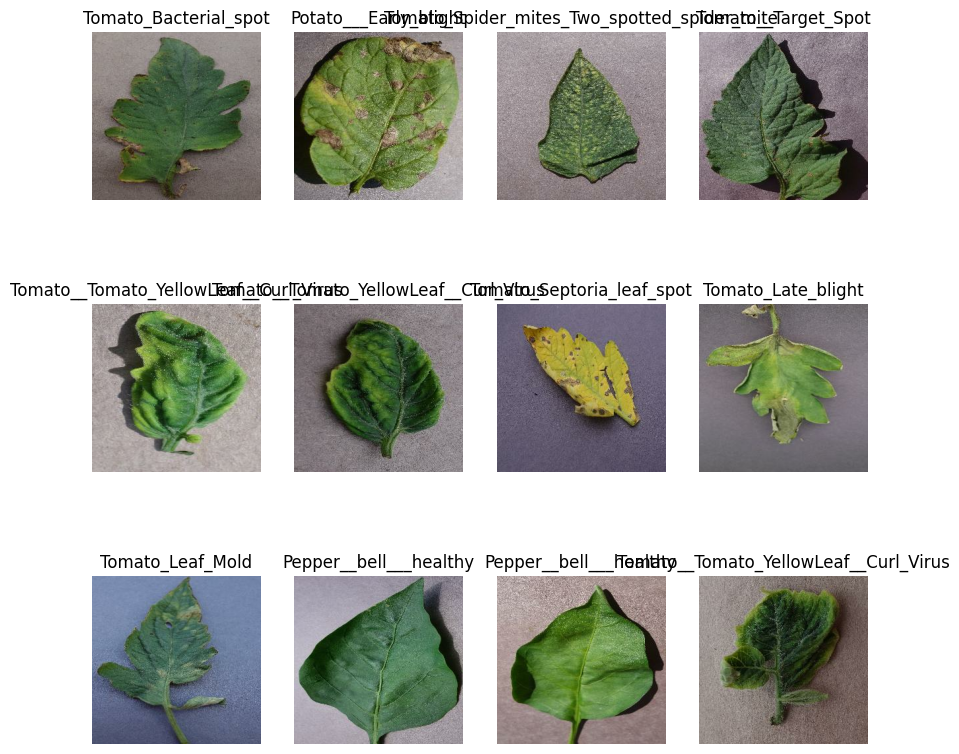

In [8]:
for image_batch, labels_batch in dataset.take(1):
    plt.figure(figsize=(10, 10))   
    for i in range(12):
        plt.subplot(3, 4, i + 1)   
        plt.imshow(image_batch[i].numpy().astype("uint8"))
        plt.axis('off')
        plt.title(class_names[labels_batch[i]])
    plt.show()

In [9]:
import tensorflow as tf

image_size = 256
batch_size = 32

dataset = tf.keras.preprocessing.image_dataset_from_directory(
    r"C:\Users\annus\Downloads\archive (1)\plant deases\PlantVillage",          
    seed=123,
    image_size=(image_size, image_size),
    batch_size=batch_size
)


train_size = int(0.8 * len(dataset))  
train_ds = dataset.take(train_size)
val_ds = dataset.skip(train_size)

print("Train batches:", len(train_ds))
print("Validation batches:", len(val_ds))

FileNotFoundError: [WinError 3] The system cannot find the path specified: 'C:\\Users\\annus\\Downloads\\archive (1)\\plant deases\\PlantVillage'

In [ ]:
test_ds = dataset.skip(516)
len(test_ds)

129

In [ ]:
val_size = 0.1
len(train_ds)*val_size

51.6

In [ ]:
val_ds = test_ds.take(51)
len(val_ds)

51

In [ ]:
test_ds = test_ds.skip(51)
len(test_ds)

78

In [ ]:
def get_dataset_partitions_tf(ds, train_split=0.8, val_split=0.1, test_split=0.1, shuffle=True, shuffle_size=10000):
    ds_size = len(ds)
    if shuffle:
        ds = ds.shuffle(shuffle_size, seed=12)

    train_size = int(train_split * ds_size)
    val_size = int(val_split * ds_size)

    train_ds = ds.take(train_size)
    val_ds = ds.skip(train_size).take(val_size)
    test_ds = ds.skip(train_size).skip(val_size)

    return train_ds, val_ds, test_ds

In [ ]:
train_ds, val_ds, test_ds = get_dataset_partitions_tf(dataset)

In [ ]:
len(train_ds), len(val_ds), len(test_ds)

(516, 64, 65)

In [ ]:
train_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
val_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 256, 256, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [ ]:
from tensorflow.keras import layers

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(256, 256),          # resize images to 256x256
    layers.Rescaling(1./255)            # normalize pixel values to [0,1]
])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

resize_and_rescale = tf.keras.Sequential([
    layers.Resizing(image_size, image_size),   
    layers.Rescaling(1.0/255)                  
])

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),  # 
    layers.RandomRotation(0.2),                    
])

In [ ]:
import tensorflow as tf
image_size = 256
batch_size = 32
input_shape = (image_size, image_size, 3)
n_classes = 38
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2,),     
    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),  
    tf.keras.layers.Conv2D(128, (3, 3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(n_classes, activation='softmax')

       
])  
model.build(input_shape=(None, image_size, image_size, 3))
model.summary()              

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    58,982,912 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,095,654 (225.43 MB)

 Trainable params: 59,095,654 (225.43 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
epochs = 1

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs,
    verbose=1,
    batch_size=batch_size
)

516/516 ━━━━━━━━━━━━━━━━━━━━ 875s 2s/step - accuracy: 0.2248 - loss: 10.1346 - val_accuracy: 0.3618 - val_loss: 2.0203


In [ ]:
scores = model.evaluate(test_ds)

65/65 ━━━━━━━━━━━━━━━━━━━━ 147s 400ms/step - accuracy: 0.3394 - loss: 2.0088


In [ ]:
history 

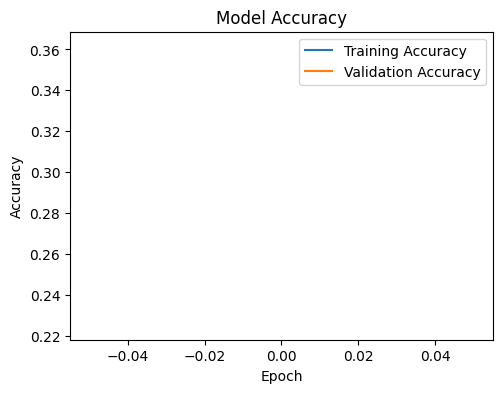

In [ ]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


[[[147 134 152]
  [144 131 149]
  [127 114 132]
  ...
  [146 137 154]
  [145 136 153]
  [148 139 156]]

 [[144 131 149]
  [141 128 146]
  [131 118 136]
  ...
  [162 153 170]
  [156 147 164]
  [160 151 168]]

 [[141 128 146]
  [137 124 142]
  [139 126 144]
  ...
  [165 156 173]
  [159 150 167]
  [161 152 169]]

 ...

 [[107  94 114]
  [116 103 123]
  [ 81  66  87]
  ...
  [120 109 125]
  [128 117 133]
  [138 127 143]]

 [[133 119 142]
  [130 116 139]
  [ 85  70  91]
  ...
  [121 110 126]
  [128 117 133]
  [135 124 140]]

 [[124 110 133]
  [115 101 124]
  [129 114 135]
  ...
  [115 104 120]
  [120 109 125]
  [126 115 131]]]
Actual Label: Pepper__bell___Bacterial_spot


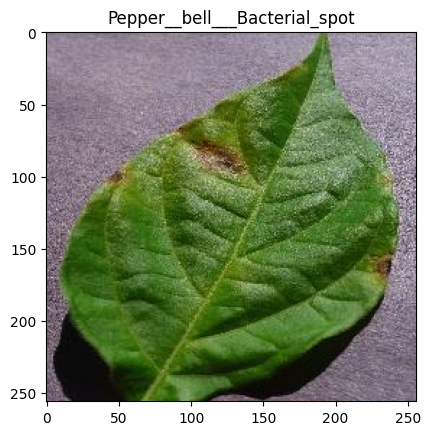

In [ ]:
import numpy as np
for image_batch, labels_batch in test_ds.take(1):
  first_image = image_batch[0].numpy().astype("uint8")
  print(first_image)
  first_label = labels_batch[0].numpy()
  plt.imshow(first_image)
  plt.title(class_names[first_label])
  print("Actual Label:", class_names[first_label])

In [ ]:
batch_predictions = model.predict(image_batch)
print(batch_predictions[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
[5.0266679e-02 3.0715469e-01 1.1838533e-01 4.8431542e-02 9.5492704e-03
 1.9810934e-02 6.2037516e-02 1.3627225e-01 3.0636318e-02 6.7573451e-02
 5.3524520e-02 3.3606891e-02 1.3578140e-02 4.3098535e-03 4.4795282e-02
 1.0090689e-06 3.9316051e-06 2.4747847e-06 9.6278052e-07 1.6826810e-06
 1.6378651e-06 4.0050945e-06 5.1516754e-06 2.1414005e-06 1.2062840e-06
 3.4403186e-06 3.7219040e-06 6.5618779e-06 1.2518237e-06 2.1094661e-06
 9.4427389e-07 8.2708657e-06 1.5175308e-06 2.7918607e-06 7.9308738e-06
 7.3179621e-07 1.6262665e-06 2.2083625e-06]


In [ ]:
def predict_image(model, image):
    image = tf.image.resize(image, (image_size, image_size))
    image = image / 255.0  # Normalize pixel values
    image = tf.expand_dims(image, axis=0)  # Add batch dimension
    predictions = model.predict(image)
    predicted_class = np.argmax(predictions[0])
    confidence = np.max(predictions[0])
    return predicted_class, confidence

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━

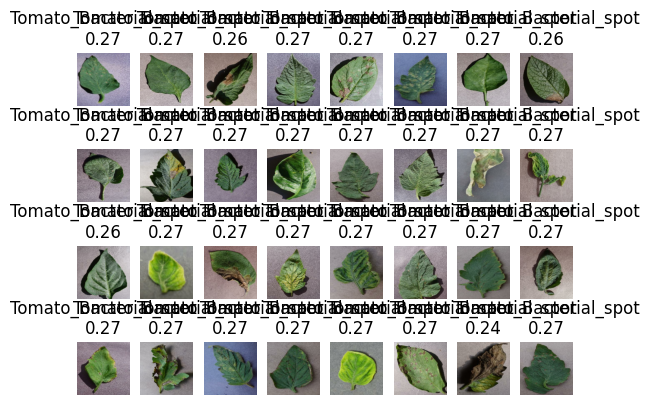

In [ ]:
for image,label in test_ds.take(1):
    for i in range(32):
        ax = plt.subplot(4, 8, i + 1)
        plt.imshow(image[i].numpy().astype("uint8"))
        plt.axis('off')
        predicted_class, confidence = predict_image(model, image[i])
        plt.title(f"{class_names[predicted_class]}\n{confidence:.2f}")
        

In [ ]:
import os
model_version = max([int(i)for i in os.listdir() if i.startswith("plant_disease_model_v") and i.endswith(".h5")], default=0) + 1

In [ ]:
model_version = 1
model.save(f"plant_disease_model_v{model_version}.h5")